In [4]:
%pip install transformer_lens
%python.exe -m pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
UsageError: Line magic function `%python.exe` not found.


## Check If I Can Replicate the Circular PCA on Days of Week

Loading GPT-2 Small...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer
Extracting residual stream activations at blocks.6.hook_resid_post...
Applying PCA to find 2D geometric structure...
Variance explained by PC1: 23.75%
Variance explained by PC2: 18.48%


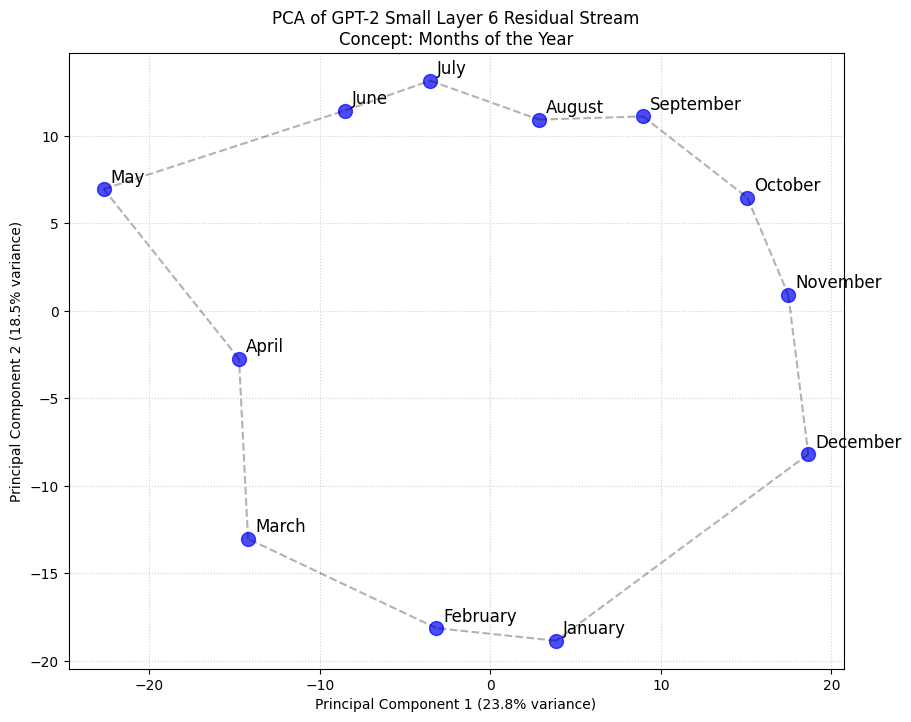

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from sklearn.decomposition import PCA


# 1. Load the target model
print("Loading GPT-2 Small...")
model = HookedTransformer.from_pretrained("gpt2-small")
    
# 2. Define the synthetic dataset (Days of the Week & Months)
# Using a standardized prefix helps isolate the conceptual representation 
# of the target word rather than just its raw token embedding.
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
months = ["January", "February", "March", "April", "May", "June", 
              "July", "August", "September", "October", "November", "December"]
    
# We will test the 'months' concept for this run
prefix = "The current month is"
prompts = [f"{prefix} {month}" for month in months]
    
# 3. Setup caching for the target layer
target_layer = 6
hook_name = f"blocks.{target_layer}.hook_resid_post"
    
# 4. Run the model and extract activations
print(f"Extracting residual stream activations at {hook_name}...")
    
# We'll store the activation of the final token (the month itself) for each prompt
extracted_activations = []
    
for prompt in prompts:
    # Run with cache returns logits and a cache dictionary
    logits, cache = model.run_with_cache(prompt)
    
    # Extract the specific activation tensor: Shape [batch, seq_len, d_model]
    layer_activations = cache[hook_name]
    
    # We want the activation of the LAST token (-1) in the sequence (the month)
    # Squeeze to remove the batch dimension, resulting in shape [d_model] (which is 768)
    last_token_activation = layer_activations[0, -1, :].detach().cpu().numpy()
    extracted_activations.append(last_token_activation)
        
# Convert list to numpy array: Shape [num_prompts, d_model]
activation_matrix = np.array(extracted_activations)
    
# 5. Apply Dimensionality Reduction (PCA)
print("Applying PCA to find 2D geometric structure...")
pca = PCA(n_components=2)
pca_results = pca.fit_transform(activation_matrix)
    
# Variance explained by the first two components
var_explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {var_explained[0]:.2%}")
print(f"Variance explained by PC2: {var_explained[1]:.2%}")
    
# 6. Visualize the Manifold
plt.figure(figsize=(10, 8))
plt.scatter(pca_results[:, 0], pca_results[:, 1], color='blue', s=100, alpha=0.7)
    
# Annotate the points with their respective labels
for i, month in enumerate(months):
    plt.annotate(month, (pca_results[i, 0], pca_results[i, 1]), 
                 fontsize=12, xytext=(5,5), textcoords='offset points')
        
# Optional: Draw lines connecting them in chronological order to highlight the loop
for i in range(len(months)):
    start_idx = i
    end_idx = (i + 1) % len(months)
    plt.plot([pca_results[start_idx, 0], pca_results[end_idx, 0]], 
             [pca_results[start_idx, 1], pca_results[end_idx, 1]], 
             'k--', alpha=0.3)

plt.title(f"PCA of GPT-2 Small Layer {target_layer} Residual Stream\nConcept: Months of the Year")
plt.xlabel(f"Principal Component 1 ({var_explained[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({var_explained[1]:.1%} variance)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Scaling to the "Unsupervised" Search:
 The clustering step (K-Means on the whole activation space) will be memory-intensive. I will likely want to randomly sample a few million tokens from a dataset like OpenWebText, run them through the model, cache all layer 6 activations, and then run an algorithm to look for high local variance across 2-3 specific dimensions.

### 100000 Tokens
#### Takes 1-2 minutes to run

In [3]:
import torch
import numpy as np
from transformer_lens import HookedTransformer
from datasets import load_dataset
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from tqdm import tqdm

def main():
    print("Loading GPT-2 Small...")
    model = HookedTransformer.from_pretrained("gpt2-small")
    
    # -----------------------------------------------------------------
    # STEP 1: Stream OpenWebText & Extract Activations Safely
    # -----------------------------------------------------------------
    print("Loading dataset stream...")
    # Using streaming=True prevents downloading the massive 40GB+ dataset
    dataset = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
    
    target_layer = 6
    hook_name = f"blocks.{target_layer}.hook_resid_post"
    
    # Configuration for our random sample
    TARGET_TOKEN_COUNT = 100_000 # Start with 100k for testing, scale to 1M+ later
    activation_buffer = []
    token_string_buffer = [] # To keep track of what words make up the clusters
    
    print(f"Extracting activations for {TARGET_TOKEN_COUNT} tokens...")
    
    for row in tqdm(dataset):
        text = row['text']
        
        # Tokenize and keep batch size manageable
        # Truncate to first 128 tokens to keep it fast
        tokens = model.to_tokens(text, truncate=True)[:, :128] 
        
        # Skip empty or very short sequences
        if tokens.shape[1] < 10: 
            continue
            
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=hook_name)
        
        # Shape: [1, seq_len, 768] -> [seq_len, 768]
        layer_acts = cache[hook_name][0].cpu().numpy() 
        str_tokens = model.to_str_tokens(tokens[0])
        
        # Avoid grabbing the BOS token or generic padding
        activation_buffer.extend(layer_acts[1:]) 
        token_string_buffer.extend(str_tokens[1:])
        
        if len(activation_buffer) >= TARGET_TOKEN_COUNT:
            break

    # Convert to standard numpy array and trim to exact size
    X = np.array(activation_buffer[:TARGET_TOKEN_COUNT])
    tokens_list = np.array(token_string_buffer[:TARGET_TOKEN_COUNT])
    
    print(f"Final Activation Matrix Shape: {X.shape} ({X.nbytes / 1e6:.2f} MB)")

    # -----------------------------------------------------------------
    # STEP 2: Mini-Batch K-Means Clustering
    # -----------------------------------------------------------------
    NUM_CLUSTERS = 500 # The "Dictionary Size" - adjust based on your hypothesis
    print(f"Running MiniBatchKMeans with {NUM_CLUSTERS} clusters...")
    
    kmeans = MiniBatchKMeans(n_clusters=NUM_CLUSTERS, batch_size=2048, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(X)

    # -----------------------------------------------------------------
    # STEP 3: Manifold Scoring (Hunting for 2D Shapes)
    # -----------------------------------------------------------------
    print("Scanning clusters for 2D Manifolds...")
    
    manifold_candidates = []
    
    for cluster_id in range(NUM_CLUSTERS):
        # Get all activations assigned to this cluster
        cluster_mask = (cluster_labels == cluster_id)
        cluster_acts = X[cluster_mask]
        cluster_tokens = tokens_list[cluster_mask]
        
        # Skip tiny clusters
        if len(cluster_acts) < 50: 
            continue
            
        # Run PCA on just this cluster
        pca = PCA(n_components=5)
        pca.fit(cluster_acts)
        var = pca.explained_variance_ratio_
        
        # The Heuristic: We want high variance in PC1 and PC2, but a sharp drop at PC3.
        # This suggests the data lies flat on a 2D plane within the 768D space.
        variance_in_2d = var[0] + var[1]
        drop_off = var[1] / (var[2] + 1e-9) # Ratio of PC2 to PC3
        
        # Tune these thresholds based on your observations
        if variance_in_2d > 0.40 and drop_off > 1.5:
            manifold_candidates.append({
                'cluster_id': cluster_id,
                'size': len(cluster_acts),
                'var_2d': variance_in_2d,
                'drop_off': drop_off,
                'sample_tokens': np.random.choice(cluster_tokens, min(10, len(cluster_tokens)), replace=False).tolist()
            })

    # -----------------------------------------------------------------
    # STEP 4: Review the Candidates
    # -----------------------------------------------------------------
    print("\n=== TOP 2D MANIFOLD CANDIDATES ===")
    
    # Sort by how sharp the drop-off is (the "flatness" of the 2D plane)
    manifold_candidates.sort(key=lambda x: x['drop_off'], reverse=True)
    
    for i, candidate in enumerate(manifold_candidates[:5]): # Print top 5
        print(f"\nCandidate {i+1} (Cluster {candidate['cluster_id']})")
        print(f"Size: {candidate['size']} tokens")
        print(f"Variance explained by PC1+PC2: {candidate['var_2d']:.2%}")
        print(f"Drop-off ratio (PC2/PC3): {candidate['drop_off']:.2f}x")
        print(f"Sample Tokens: {candidate['sample_tokens']}")

if __name__ == "__main__":
    main()

Loading GPT-2 Small...
Loaded pretrained model gpt2-small into HookedTransformer
Loading dataset stream...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Extracting activations for 100000 tokens...


787it [00:33, 23.52it/s]


Final Activation Matrix Shape: (100000, 768) (307.20 MB)
Running MiniBatchKMeans with 500 clusters...
Scanning clusters for 2D Manifolds...

=== TOP 2D MANIFOLD CANDIDATES ===

Candidate 1 (Cluster 35)
Size: 85 tokens
Variance explained by PC1+PC2: 42.11%
Drop-off ratio (PC2/PC3): 2.62x
Sample Tokens: ['.', ' Sir', '.', ' Dr', ' Mr', ' Ms', '.', ' Mr', 'Ms', ' Dr']

Candidate 2 (Cluster 435)
Size: 67 tokens
Variance explained by PC1+PC2: 49.67%
Drop-off ratio (PC2/PC3): 1.93x
Sample Tokens: ['�', '�', '�', '�', '�', '�', '�', '�', '�', '�']

Candidate 3 (Cluster 186)
Size: 75 tokens
Variance explained by PC1+PC2: 43.98%
Drop-off ratio (PC2/PC3): 1.71x
Sample Tokens: [' (', ' (', ' (', '(', ' (', ' (', ' (', ' (', ' (', ' (']

Candidate 4 (Cluster 170)
Size: 68 tokens
Variance explained by PC1+PC2: 43.42%
Drop-off ratio (PC2/PC3): 1.66x
Sample Tokens: [')', ')', ')', ')', ')', ')', ')', ')', ')', ')']


### 1000000 Tokens 
#### Takes 5-10 minutes to run

In [ ]:
def main():
    print("Loading GPT-2 Small...")
    model = HookedTransformer.from_pretrained("gpt2-small")
    
    # -----------------------------------------------------------------
    # STEP 1: Stream OpenWebText & Extract Activations Safely
    # -----------------------------------------------------------------
    print("Loading dataset stream...")
    # Using streaming=True prevents downloading the massive 40GB+ dataset
    dataset = load_dataset("Skylion007/openwebtext", split="train", streaming=True)
    
    target_layer = 6
    hook_name = f"blocks.{target_layer}.hook_resid_post"
    
    # Configuration for our random sample
    TARGET_TOKEN_COUNT = 1_000_000 # Start with 100k for testing, scale to 1M+ later
    activation_buffer = []
    token_string_buffer = [] # To keep track of what words make up the clusters
    
    print(f"Extracting activations for {TARGET_TOKEN_COUNT} tokens...")
    
    for row in tqdm(dataset):
        text = row['text']
        
        # Tokenize and keep batch size manageable
        # Truncate to first 128 tokens to keep it fast
        tokens = model.to_tokens(text, truncate=True)[:, :128] 
        
        # Skip empty or very short sequences
        if tokens.shape[1] < 10: 
            continue
            
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=hook_name)
        
        # Shape: [1, seq_len, 768] -> [seq_len, 768]
        layer_acts = cache[hook_name][0].cpu().numpy() 
        str_tokens = model.to_str_tokens(tokens[0])
        
        # Avoid grabbing the BOS token or generic padding
        activation_buffer.extend(layer_acts[1:]) 
        token_string_buffer.extend(str_tokens[1:])
        
        if len(activation_buffer) >= TARGET_TOKEN_COUNT:
            break

    # Convert to standard numpy array and trim to exact size
    X = np.array(activation_buffer[:TARGET_TOKEN_COUNT])
    tokens_list = np.array(token_string_buffer[:TARGET_TOKEN_COUNT])
    
    print(f"Final Activation Matrix Shape: {X.shape} ({X.nbytes / 1e6:.2f} MB)")

    # -----------------------------------------------------------------
    # STEP 2: Mini-Batch K-Means Clustering
    # -----------------------------------------------------------------
    NUM_CLUSTERS = 500 # The "Dictionary Size" - adjust based on your hypothesis
    print(f"Running MiniBatchKMeans with {NUM_CLUSTERS} clusters...")
    
    kmeans = MiniBatchKMeans(n_clusters=NUM_CLUSTERS, batch_size=2048, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(X)

    # -----------------------------------------------------------------
    # STEP 3: Manifold Scoring (Hunting for 2D Shapes)
    # -----------------------------------------------------------------
    print("Scanning clusters for 2D Manifolds...")
    
    manifold_candidates = []
    
    for cluster_id in range(NUM_CLUSTERS):
        # Get all activations assigned to this cluster
        cluster_mask = (cluster_labels == cluster_id)
        cluster_acts = X[cluster_mask]
        cluster_tokens = tokens_list[cluster_mask]
        
        # Skip tiny clusters
        if len(cluster_acts) < 50: 
            continue
            
        # Run PCA on just this cluster
        pca = PCA(n_components=5)
        pca.fit(cluster_acts)
        var = pca.explained_variance_ratio_
        
        # The Heuristic: We want high variance in PC1 and PC2, but a sharp drop at PC3.
        # This suggests the data lies flat on a 2D plane within the 768D space.
        variance_in_2d = var[0] + var[1]
        drop_off = var[1] / (var[2] + 1e-9) # Ratio of PC2 to PC3
        
        # Tune these thresholds based on your observations
        if variance_in_2d > 0.40 and drop_off > 1.5:
            manifold_candidates.append({
                'cluster_id': cluster_id,
                'size': len(cluster_acts),
                'var_2d': variance_in_2d,
                'drop_off': drop_off,
                'sample_tokens': np.random.choice(cluster_tokens, min(10, len(cluster_tokens)), replace=False).tolist()
            })

    # -----------------------------------------------------------------
    # STEP 4: Review the Candidates
    # -----------------------------------------------------------------
    print("\n=== TOP 2D MANIFOLD CANDIDATES ===")
    
    # Sort by how sharp the drop-off is (the "flatness" of the 2D plane)
    manifold_candidates.sort(key=lambda x: x['drop_off'], reverse=True)
    
    for i, candidate in enumerate(manifold_candidates[:5]): # Print top 5
        print(f"\nCandidate {i+1} (Cluster {candidate['cluster_id']})")
        print(f"Size: {candidate['size']} tokens")
        print(f"Variance explained by PC1+PC2: {candidate['var_2d']:.2%}")
        print(f"Drop-off ratio (PC2/PC3): {candidate['drop_off']:.2f}x")
        print(f"Sample Tokens: {candidate['sample_tokens']}")

if __name__ == "__main__":
    main()

Loading GPT-2 Small...
Loaded pretrained model gpt2-small into HookedTransformer
Loading dataset stream...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Extracting activations for 1000000 tokens...


7874it [04:26, 29.59it/s]


Final Activation Matrix Shape: (1000000, 768) (3072.00 MB)
Running MiniBatchKMeans with 500 clusters...
Scanning clusters for 2D Manifolds...

=== TOP 2D MANIFOLD CANDIDATES ===

Candidate 1 (Cluster 170)
Size: 779 tokens
Variance explained by PC1+PC2: 86.82%
Drop-off ratio (PC2/PC3): 2.84x
Sample Tokens: ['The', 'The', 'The', 'The', 'The', 'The', 'The', 'The', 'The', 'The']

Candidate 2 (Cluster 498)
Size: 676 tokens
Variance explained by PC1+PC2: 47.77%
Drop-off ratio (PC2/PC3): 2.64x
Sample Tokens: [' (', ' ((', ' (', ' (', ' (', ' (', ' (', '(', ' (', ' (']

Candidate 3 (Cluster 343)
Size: 1074 tokens
Variance explained by PC1+PC2: 40.20%
Drop-off ratio (PC2/PC3): 2.15x
Sample Tokens: ['While', ' while', ' While', ' while', ' while', ' Despite', ' While', 'While', ' While', 'Though']

Candidate 4 (Cluster 236)
Size: 729 tokens
Variance explained by PC1+PC2: 45.12%
Drop-off ratio (PC2/PC3): 1.72x
Sample Tokens: ['\n', '\n', '\n', '\n', '\n', '\n', '\n', '\n', '\n', '\n']

Candidate 